## Problem 1

Evaluation Metrics For Information Splitting (Entropy):
Training Accuracy: 0.9994565217391305
Training Error: 0.0005434782608695343
Training F1 Score: 0.9992967651195499
Training AUC Score: 0.9992972593113141
Testing Accuracy: 0.9315960912052117
Testing Error: 0.0684039087947883
Testing F1 Score: 0.9176470588235294
Testing AUC Score: 0.9274011299435028

Evaluation Metrics For Gini Index:
Training Accuracy: 0.9994565217391305
Training Error: 0.0005434782608695343
Training F1 Score: 0.9992967651195499
Training AUC Score: 0.9992972593113141
Testing Accuracy: 0.9185667752442996
Testing Error: 0.08143322475570036
Testing F1 Score: 0.9019607843137255
Testing AUC Score: 0.9140591047370707

Entropy Criterion:
  Optimal Depth: 15
  Min Test Error: 0.0630
  Train Error at Optimal Depth: 0.0101

Gini Criterion:
  Optimal Depth: 12
  Min Test Error: 0.0717
  Train Error at Optimal Depth: 0.0228


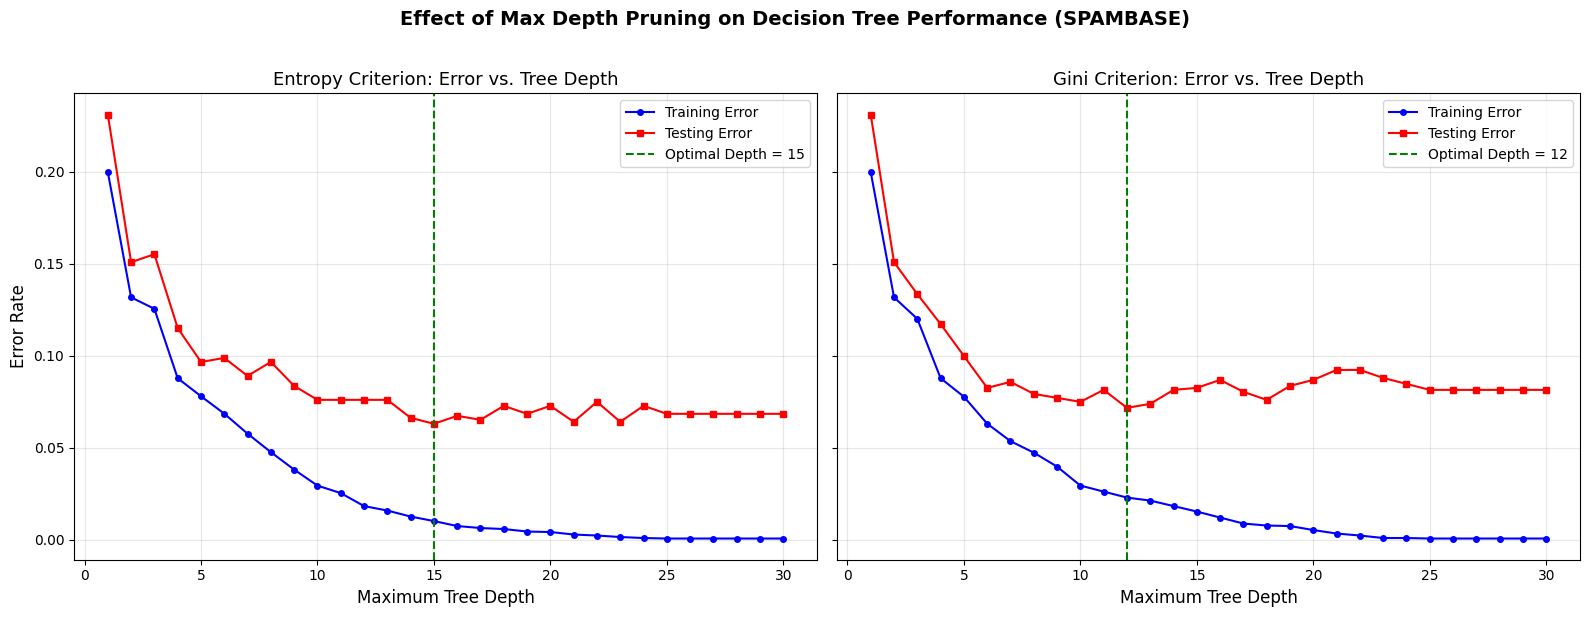

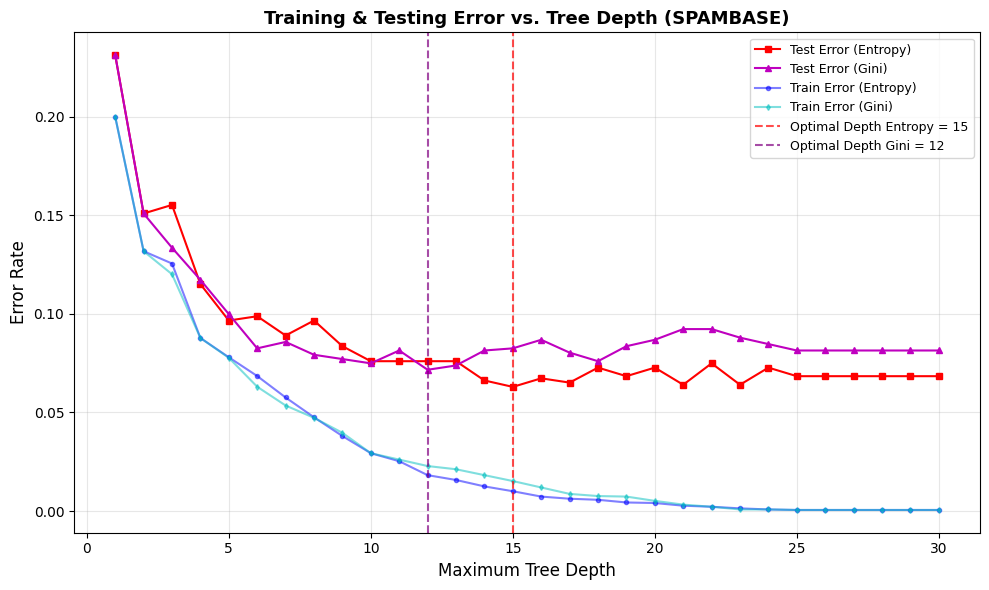

In [15]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, recall_score, roc_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("spambase/spambase.data", header=None)

# Split the dataset into features and target variable
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Information Gain Splitting Criteria and Gini-based classifiers 

dt_classifier_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_classifier_entropy.fit(X_train, y_train)
y_pred = dt_classifier_entropy.predict(X_test)
y_train_pred = dt_classifier_entropy.predict(X_train)

print("Evaluation Metrics For Information Splitting (Entropy):")
training_accuracy = np.mean(y_train_pred == y_train)
print("Training Accuracy:", training_accuracy)
print("Training Error:", 1 - training_accuracy)
print("Training F1 Score:", f1_score(y_train, y_train_pred))
print("Training AUC Score:", roc_auc_score(y_train, y_train_pred))
testing_accuracy = np.mean(y_pred == y_test)
print("Testing Accuracy:", testing_accuracy)
print("Testing Error:", 1 - testing_accuracy)
print("Testing F1 Score:", f1_score(y_test, y_pred))
print("Testing AUC Score:", roc_auc_score(y_test, y_pred))

dt_classifier_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_classifier_gini.fit(X_train, y_train)
y_pred_gini = dt_classifier_gini.predict(X_test)
y_train_pred_gini = dt_classifier_gini.predict(X_train)

print("\nEvaluation Metrics For Gini Index:")
training_accuracy_gini = np.mean(y_train_pred_gini == y_train)
print("Training Accuracy:", training_accuracy_gini)
print("Training Error:", 1 - training_accuracy_gini)
print("Training F1 Score:", f1_score(y_train, y_train_pred_gini))
print("Training AUC Score:", roc_auc_score(y_train, y_train_pred_gini))
testing_accuracy_gini = np.mean(y_pred_gini == y_test)
print("Testing Accuracy:", testing_accuracy_gini)
print("Testing Error:", 1 - testing_accuracy_gini)
print("Testing F1 Score:", f1_score(y_test, y_pred_gini))
print("Testing AUC Score:", roc_auc_score(y_test, y_pred_gini))

# Test depths from 1 to 30 for both criteria
max_depth_range = range(1, 31)  

# Storage for errors
train_errors_entropy = []
test_errors_entropy = []
train_errors_gini = []
test_errors_gini = []

for depth in max_depth_range:
    # Entropy criterion with max_depth constraint
    dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    dt_entropy.fit(X_train, y_train)
    train_errors_entropy.append(1 - dt_entropy.score(X_train, y_train))
    test_errors_entropy.append(1 - dt_entropy.score(X_test, y_test))

    # Gini criterion with max_depth constraint
    dt_gini = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    dt_gini.fit(X_train, y_train)
    train_errors_gini.append(1 - dt_gini.score(X_train, y_train))
    test_errors_gini.append(1 - dt_gini.score(X_test, y_test))

# Identify optimal depths (minimum test error)
optimal_depth_entropy = list(max_depth_range)[np.argmin(test_errors_entropy)]
optimal_depth_gini = list(max_depth_range)[np.argmin(test_errors_gini)]


print(f"\nEntropy Criterion:")
print(f"  Optimal Depth: {optimal_depth_entropy}")
print(f"  Min Test Error: {min(test_errors_entropy):.4f}")
print(f"  Train Error at Optimal Depth: {train_errors_entropy[optimal_depth_entropy - 1]:.4f}")

print(f"\nGini Criterion:")
print(f"  Optimal Depth: {optimal_depth_gini}")
print(f"  Min Test Error: {min(test_errors_gini):.4f}")
print(f"  Train Error at Optimal Depth: {train_errors_gini[optimal_depth_gini - 1]:.4f}")


fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Entropy plot
axes[0].plot(max_depth_range, train_errors_entropy, 'b-o', markersize=4, label='Training Error')
axes[0].plot(max_depth_range, test_errors_entropy, 'r-s', markersize=4, label='Testing Error')
axes[0].axvline(x=optimal_depth_entropy, color='green', linestyle='--', linewidth=1.5,
                label=f'Optimal Depth = {optimal_depth_entropy}')
axes[0].set_xlabel('Maximum Tree Depth', fontsize=12)
axes[0].set_ylabel('Error Rate', fontsize=12)
axes[0].set_title('Entropy Criterion: Error vs. Tree Depth', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].set_xticks(range(0, 31, 5))
axes[0].grid(True, alpha=0.3)

# Gini plot
axes[1].plot(max_depth_range, train_errors_gini, 'b-o', markersize=4, label='Training Error')
axes[1].plot(max_depth_range, test_errors_gini, 'r-s', markersize=4, label='Testing Error')
axes[1].axvline(x=optimal_depth_gini, color='green', linestyle='--', linewidth=1.5,
                label=f'Optimal Depth = {optimal_depth_gini}')
axes[1].set_xlabel('Maximum Tree Depth', fontsize=12)
axes[1].set_title('Gini Criterion: Error vs. Tree Depth', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_xticks(range(0, 31, 5))
axes[1].grid(True, alpha=0.3)

plt.suptitle('Effect of Max Depth Pruning on Decision Tree Performance (SPAMBASE)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Combined plot for both criteria
plt.figure(figsize=(10, 6))
plt.plot(max_depth_range, test_errors_entropy, 'r-s', markersize=4, label='Test Error (Entropy)')
plt.plot(max_depth_range, test_errors_gini, 'm-^', markersize=4, label='Test Error (Gini)')
plt.plot(max_depth_range, train_errors_entropy, 'b-o', markersize=3, alpha=0.5, label='Train Error (Entropy)')
plt.plot(max_depth_range, train_errors_gini, 'c-d', markersize=3, alpha=0.5, label='Train Error (Gini)')
plt.axvline(x=optimal_depth_entropy, color='red', linestyle='--', alpha=0.7,
            label=f'Optimal Depth Entropy = {optimal_depth_entropy}')
plt.axvline(x=optimal_depth_gini, color='purple', linestyle='--', alpha=0.7,
            label=f'Optimal Depth Gini = {optimal_depth_gini}')
plt.xlabel('Maximum Tree Depth', fontsize=12)
plt.ylabel('Error Rate', fontsize=12)
plt.title('Training & Testing Error vs. Tree Depth (SPAMBASE)', fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Problem 2

Random Forest Metrics:
     Train Acc  Train F1  Train AUC  Test Acc  Test F1  Test AUC
T                                                               
10      0.9951    0.9937     0.9999    0.9425   0.9289    0.9833
50      0.9995    0.9993     1.0000    0.9555   0.9457    0.9870
100     0.9995    0.9993     1.0000    0.9577   0.9488    0.9871
500     0.9995    0.9993     1.0000    0.9544   0.9449    0.9866


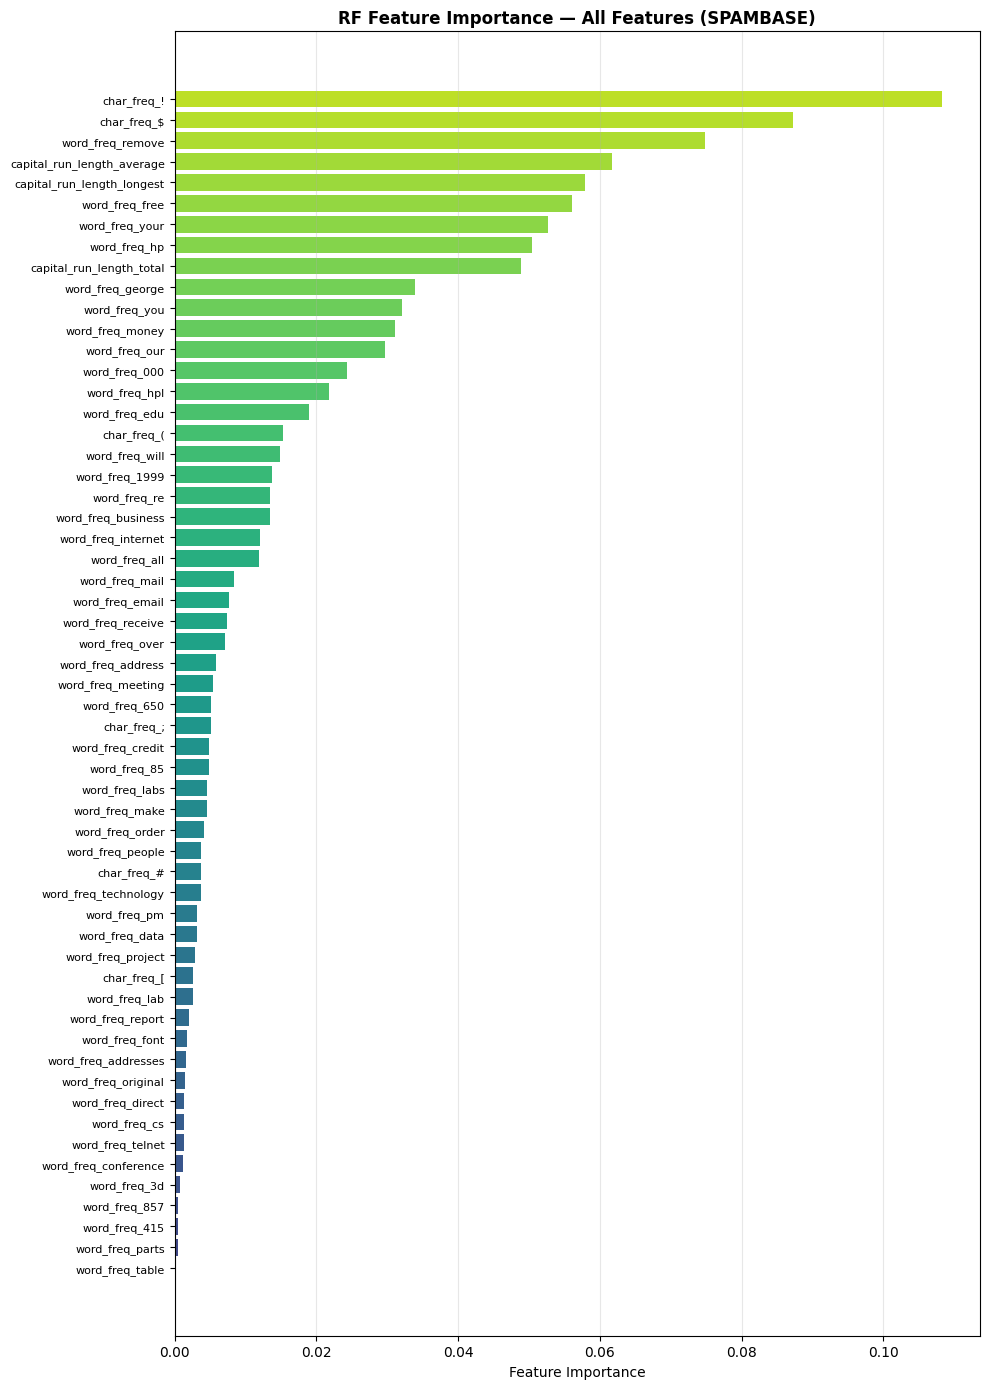

In [ ]:

# Train Random Forests with varying T
n_trees_list = [10, 50, 100, 500]
results = []

for T in n_trees_list:
    rf = RandomForestClassifier(n_estimators=T, criterion='entropy', random_state=42)
    rf.fit(X_train, y_train)

    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    y_train_proba = rf.predict_proba(X_train)[:, 1]
    y_test_proba = rf.predict_proba(X_test)[:, 1]

    results.append({
        'T': T,
        'Train Acc': accuracy_score(y_train, y_train_pred),
        'Train F1': f1_score(y_train, y_train_pred),
        'Train AUC': roc_auc_score(y_train, y_train_proba),
        'Test Acc': accuracy_score(y_test, y_test_pred),
        'Test F1': f1_score(y_test, y_test_pred),
        'Test AUC': roc_auc_score(y_test, y_test_proba),
    })

results_df = pd.DataFrame(results).set_index('T')
print("Random Forest Metrics:")
print(results_df.round(4))


feature_names = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our',
    'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail',
    'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses',
    'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp',
    'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs',
    'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
    'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re',
    'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'char_freq_$', 'char_freq_#',
    'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total',
]

# Load and split data
df = pd.read_csv("spambase/spambase.data", header=None)
df.columns = feature_names + ['label']
X = df[feature_names]
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Part 1: Train Random Forests with varying T
n_trees_list = [10, 50, 100, 500]
results = []

for T in n_trees_list:
    rf = RandomForestClassifier(n_estimators=T, criterion='entropy', random_state=42)
    rf.fit(X_train, y_train)

    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    y_train_proba = rf.predict_proba(X_train)[:, 1]
    y_test_proba = rf.predict_proba(X_test)[:, 1]

    results.append({
        'T': T,
        'Train Acc': accuracy_score(y_train, y_train_pred),
        'Train F1': f1_score(y_train, y_train_pred),
        'Train AUC': roc_auc_score(y_train, y_train_proba),
        'Test Acc': accuracy_score(y_test, y_test_pred),
        'Test F1': f1_score(y_test, y_test_pred),
        'Test AUC': roc_auc_score(y_test, y_test_proba),
    })

results_df = pd.DataFrame(results).set_index('T')
print("Random Forest Metrics:")
print(results_df.round(4))

# Part 3: Feature importance plot
rf500 = RandomForestClassifier(n_estimators=500, criterion='entropy', random_state=42)
rf500.fit(X_train, y_train)
importances = rf500.feature_importances_
sorted_idx = np.argsort(importances)
sorted_names = [X.columns[i] for i in sorted_idx]

plt.figure(figsize=(10, 14))
plt.barh(range(len(importances)), importances[sorted_idx],
         color=plt.cm.viridis(np.linspace(0.2, 0.9, len(importances))))
plt.yticks(range(len(importances)), sorted_names, fontsize=8)
plt.xlabel('Feature Importance')
plt.title('RF Feature Importance', fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Print all feature importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)
importance_df.index += 1
print("\nFeature Importances:")
print(importance_df.round(4).to_string())

## Problem 3

AdaBoost Metrics:
     Train Acc  Train F1  Train AUC  Test Acc  Test F1  Test AUC
T                                                               
10      0.9060    0.8769     0.9623    0.8947   0.8729    0.9631
50      0.9342    0.9139     0.9792    0.9262   0.9103    0.9776
100     0.9408    0.9220     0.9838    0.9370   0.9237    0.9811
500     0.9516    0.9368     0.9905    0.9501   0.9403    0.9830

Random Forest Metrics:
     Train Acc  Train F1  Train AUC  Test Acc  Test F1  Test AUC
T                                                               
10      0.9951    0.9937     0.9999    0.9425   0.9289    0.9833
50      0.9995    0.9993     1.0000    0.9555   0.9457    0.9870
100     0.9995    0.9993     1.0000    0.9577   0.9488    0.9871
500     0.9995    0.9993     1.0000    0.9544   0.9449    0.9866


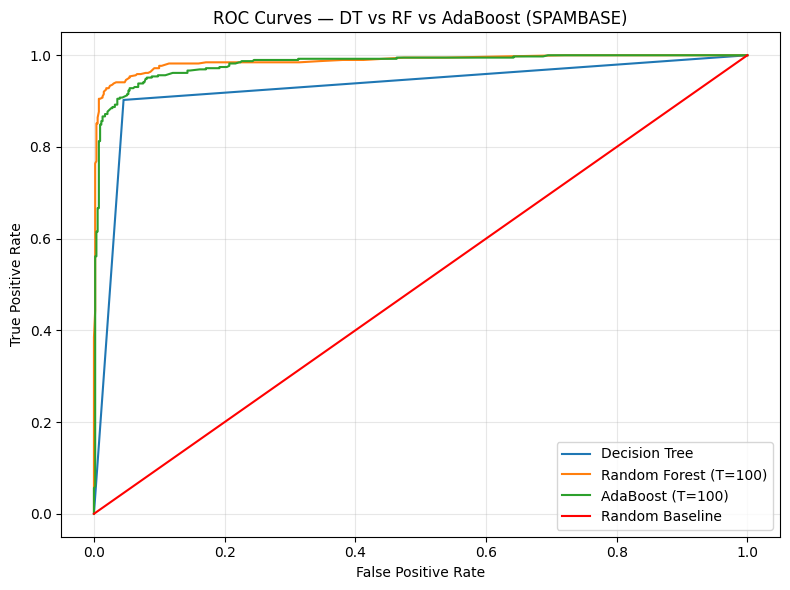

In [14]:
# Train AdaBoost with varying T
n_trees_list = [10, 50, 100, 500]
ada_results = []

for T in n_trees_list:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=T, random_state=42
    )
    ada.fit(X_train, y_train)

    y_train_pred = ada.predict(X_train)
    y_test_pred = ada.predict(X_test)
    y_train_proba = ada.predict_proba(X_train)[:, 1]
    y_test_proba = ada.predict_proba(X_test)[:, 1]

    ada_results.append({
        'T': T,
        'Train Acc': accuracy_score(y_train, y_train_pred),
        'Train F1': f1_score(y_train, y_train_pred),
        'Train AUC': roc_auc_score(y_train, y_train_proba),
        'Test Acc': accuracy_score(y_test, y_test_pred),
        'Test F1': f1_score(y_test, y_test_pred),
        'Test AUC': roc_auc_score(y_test, y_test_proba),
    })

ada_df = pd.DataFrame(ada_results).set_index('T')
print("AdaBoost Metrics:")
print(ada_df.round(4))

# Retrain Random Forest for side-by-side comparison
rf_results = []

for T in n_trees_list:
    rf = RandomForestClassifier(n_estimators=T, criterion='entropy', random_state=42)
    rf.fit(X_train, y_train)

    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    y_train_proba = rf.predict_proba(X_train)[:, 1]
    y_test_proba = rf.predict_proba(X_test)[:, 1]

    rf_results.append({
        'T': T,
        'Train Acc': accuracy_score(y_train, y_train_pred),
        'Train F1': f1_score(y_train, y_train_pred),
        'Train AUC': roc_auc_score(y_train, y_train_proba),
        'Test Acc': accuracy_score(y_test, y_test_pred),
        'Test F1': f1_score(y_test, y_test_pred),
        'Test AUC': roc_auc_score(y_test, y_test_proba),
    })

rf_df = pd.DataFrame(rf_results).set_index('T')
print("\nRandom Forest Metrics:")
print(rf_df.round(4))

# ROC curves for DT, RF(100), AdaBoost(100)
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train, y_train)

rf100 = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=42)
rf100.fit(X_train, y_train)

ada100 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100, random_state=42
)
ada100.fit(X_train, y_train)

plt.figure(figsize=(8, 6))

models = {
    'Decision Tree': dt,
    'Random Forest (T=100)': rf100,
    'AdaBoost (T=100)': ada100,
}

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name}')

plt.plot([0, 1], [0, 1], '-r', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — DT vs RF vs AdaBoost (SPAMBASE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Problem 4

In [16]:
# Custom Naive Bayes Classifier for categorical data
class NaiveBayesClassifier:
    def __init__(self):
        self.priors = {}
        self.cond_probs = {}
        self.classes = None

    def fit(self, X, y):
        self.classes = y.unique()

        # Prior probabilities P(Y = c)
        class_counts = y.value_counts()
        for c in self.classes:
            self.priors[c] = class_counts[c] / len(y)

        # Conditional probabilities P(Xi = x | Y = c) with Laplace smoothing
        for col in X.columns:
            self.cond_probs[col] = {}
            possible_values = X[col].unique()
            num_values = len(possible_values)

            for c in self.classes:
                self.cond_probs[col][c] = {}
                subset = X.loc[y == c, col]
                count_c = len(subset)
                value_counts = subset.value_counts()

                for val in possible_values:
                    count_val = value_counts.get(val, 0)
                    self.cond_probs[col][c][val] = (count_val + 1) / (count_c + num_values)

    def predict(self, X):
        predictions = []
        for _, row in X.iterrows():
            best_class = None
            best_log_prob = -np.inf

            for c in self.classes:
                log_prob = np.log(self.priors[c])
                for col in X.columns:
                    val = row[col]
                    if val in self.cond_probs[col][c]:
                        log_prob += np.log(self.cond_probs[col][c][val])
                    else:
                        # Unseen value fallback
                        num_values = len(self.cond_probs[col][c])
                        count_c = sum(self.cond_probs[col][c].values())
                        log_prob += np.log(1 / (count_c + num_values))

                if log_prob > best_log_prob:
                    best_log_prob = log_prob
                    best_class = c

            predictions.append(best_class)
        return predictions


# Load data
df = pd.read_csv("mushroom/agaricus-lepiota.data", header=None)
y = df.iloc[:, 0]
X = df.iloc[:, 1:]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Custom Naive Bayes
nb = NaiveBayesClassifier()
nb.fit(X_train, y_train)

print("Prior Probabilities:")
for c in nb.classes:
    print(f"  P(Y={c}) = {nb.priors[c]:.4f}")

y_pred_custom = nb.predict(X_test)

custom_acc = accuracy_score(y_test, y_pred_custom)
custom_prec = precision_score(y_test, y_pred_custom, pos_label='p')
custom_rec = recall_score(y_test, y_pred_custom, pos_label='p')
custom_f1 = f1_score(y_test, y_pred_custom, pos_label='p')

print("\nCustom Naive Bayes Metrics:")
print(f"  Accuracy:  {custom_acc:.4f}")
print(f"  Precision: {custom_prec:.4f}")
print(f"  Recall:    {custom_rec:.4f}")
print(f"  F1 Score:  {custom_f1:.4f}")

# Compare with sklearn CategoricalNB
ord_enc = OrdinalEncoder()
X_train_enc = ord_enc.fit_transform(X_train)
X_test_enc = ord_enc.transform(X_test)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

sklearn_nb = CategoricalNB(alpha=1.0)
sklearn_nb.fit(X_train_enc, y_train_enc)
y_pred_sklearn = le.inverse_transform(sklearn_nb.predict(X_test_enc))

sklearn_acc = accuracy_score(y_test, y_pred_sklearn)
sklearn_prec = precision_score(y_test, y_pred_sklearn, pos_label='p')
sklearn_rec = recall_score(y_test, y_pred_sklearn, pos_label='p')
sklearn_f1 = f1_score(y_test, y_pred_sklearn, pos_label='p')

print("\nSklearn CategoricalNB Metrics:")
print(f"  Accuracy:  {sklearn_acc:.4f}")
print(f"  Precision: {sklearn_prec:.4f}")
print(f"  Recall:    {sklearn_rec:.4f}")
print(f"  F1 Score:  {sklearn_f1:.4f}")

comparison = pd.DataFrame({
    'Custom NB': [custom_acc, custom_prec, custom_rec, custom_f1],
    'Sklearn NB': [sklearn_acc, sklearn_prec, sklearn_rec, sklearn_f1],
}, index=['Accuracy', 'Precision', 'Recall', 'F1 Score'])

print("\nComparison:")
print(comparison.round(4))

Prior Probabilities:
  P(Y=p) = 0.4801
  P(Y=e) = 0.5199

Custom Naive Bayes Metrics:
  Accuracy:  0.9488
  Precision: 0.9901
  Recall:    0.9041
  F1 Score:  0.9451

Sklearn CategoricalNB Metrics:
  Accuracy:  0.9488
  Precision: 0.9901
  Recall:    0.9041
  F1 Score:  0.9451

Comparison:
           Custom NB  Sklearn NB
Accuracy      0.9488      0.9488
Precision     0.9901      0.9901
Recall        0.9041      0.9041
F1 Score      0.9451      0.9451
